# EDA bộ dữ liệu IMPROVE cho dự đoán đáp ứng thuốc

Notebook này phân tích benchmark trong paper **Benchmarking Community Drug Response Prediction Models: Datasets, Models, Tools, and Metrics for Cross-Dataset Generalization Analysis** (arXiv:2503.14356v1).

Mục tiêu:
- kiểm tra quy mô và chất lượng response của 5 study: CCLE, CTRPv2, gCSI, GDSCv1, GDSCv2;
- so sánh phân phối AUC và mức mất cân bằng giữa study;
- đo overlap về cell line, drug và cặp cell-drug để đánh giá khả năng cross-dataset;
- kiểm tra độ nhất quán response trên các cặp xuất hiện ở nhiều study;
- đánh giá nhanh gene expression, Mordred descriptor và ECFP;
- audit 10 bộ split 80/10/10 được paper cung cấp.

> Trong benchmark, `auc` đã được chuẩn hóa về [0, 1]; AUC thấp biểu thị đáp ứng mạnh hơn (ức chế tăng trưởng cao hơn).

In [6]:
from pathlib import Path
from itertools import combinations
import csv
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#376996', '#E07A5F', '#3D9970', '#8E6C8A', '#E9C46A']
STUDIES = ['CCLE', 'CTRPv2', 'gCSI', 'GDSCv1', 'GDSCv2']
RANDOM_STATE = 42

## 1. Xác định dữ liệu và đọc response

Cell dưới tự tìm thư mục dữ liệu dù kernel được mở từ thư mục gốc hay từ `notebooks/`.

In [7]:
# IMPROVE được setup_improve.sh clone cạnh repository này.
improve_candidates = [Path('../IMPROVE'), Path('../../IMPROVE')]
IMPROVE_DIR = next((p.resolve() for p in improve_candidates if (p / 'improvelib').is_dir()), None)
if IMPROVE_DIR is None:
    raise ImportError('Không tìm thấy IMPROVE. Hãy chạy setup_improve.sh trước.')
if str(IMPROVE_DIR) not in sys.path:
    sys.path.insert(0, str(IMPROVE_DIR))

import improvelib.utils as frm

candidates = [
    Path('data/csa_data/raw_data'),
    Path('../data/csa_data/raw_data'),
    Path('csa_data/raw_data'),
]
DATA_DIR = next((p.resolve() for p in candidates if (p / 'y_data/response.tsv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Không tìm thấy IMPROVE data. Hãy chạy setup_improve.sh hoặc đặt dữ liệu tại '
        'data/csa_data/raw_data.'
    )

X_DIR = DATA_DIR / 'x_data'
SPLIT_DIR = DATA_DIR / 'splits'
RESPONSE_FILE = DATA_DIR / 'y_data/response.tsv'
ALL_SPLIT_FILES = [f'{study}_all.txt' for study in STUDIES]

# Loader chuẩn của IMPROVE giữ nguyên global row index trong cột `index`.
response = frm.get_y_data(
    split_file=ALL_SPLIT_FILES,
    benchmark_dir=DATA_DIR,
    y_data_file='response.tsv',
    split_id='index',
)
print('DATA_DIR =', DATA_DIR)
print('IMPROVE_DIR =', IMPROVE_DIR)

response['source'] = pd.Categorical(response['source'], categories=STUDIES, ordered=True)
print(f'Response shape: {response.shape[0]:,} rows x {response.shape[1]:,} columns')
display(response.head())
display(response.dtypes.to_frame('dtype').T)

DATA_DIR = /Users/vietanh/Desktop/ML-Predicting-drug-response/data/csa_data/raw_data
IMPROVE_DIR = /Users/vietanh/Desktop/IMPROVE
Response shape: 587,709 rows x 15 columns


/Users/vietanh/Desktop/IMPROVE/improvelib/utils.py:45: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(response_path, sep=sep)


,index,source,improve_sample_id,improve_chem_id,study,auc,ic50,ec50,ec50se,r2fit,einf,hs,aac1,auc1,dss1
0,0,CCLE,ACH-000956,Drug_749,fake_exp,0.7153,5.6600,5.6600,0.6867,0.9533,0.0000,0.6669,0.2240,0.7760,0.1661
1,1,CCLE,ACH-000956,Drug_1326,fake_exp,0.9579,NaN,7.0230,0.7111,0.4332,0.9164,4.0000,0.0459,0.9541,0.0000
2,2,CCLE,ACH-000956,Drug_490,fake_exp,0.4130,7.5460,7.5510,0.0385,0.9948,0.0082,1.3380,0.6909,0.3091,0.6605
3,3,CCLE,ACH-000956,Drug_558,fake_exp,0.8004,5.1980,5.1980,11.7100,0.9944,0.0000,4.0000,0.0392,0.9608,0.0291
4,4,CCLE,ACH-000956,Drug_895,fake_exp,0.5071,7.0930,7.1490,0.3175,0.8069,0.0607,1.0150,0.5470,0.4530,0.5037


,index,source,improve_sample_id,improve_chem_id,study,auc,ic50,ec50,ec50se,r2fit,einf,hs,aac1,auc1,dss1
dtype,int64,category,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


## 2. Kiểm tra chất lượng dữ liệu response

Ngoài missing value và miền giá trị, ta kiểm tra duplicate theo khóa `(source, improve_sample_id, improve_chem_id)`. Duplicate không nên bị xóa mù quáng vì một study có thể chứa nhiều thí nghiệm/curve cho cùng cặp; khi so sánh cross-study ở phần sau, notebook sẽ aggregate bằng mean.

In [8]:
key_cols = ['source', 'improve_sample_id', 'improve_chem_id']
quality = pd.DataFrame({
    'dtype': response.dtypes.astype(str),
    'missing_n': response.isna().sum(),
    'missing_pct': response.isna().mean().mul(100),
    'n_unique': response.nunique(dropna=True),
}).sort_values('missing_pct', ascending=False)
display(quality)

duplicate_mask = response.duplicated(key_cols, keep=False)
print(f'Exact duplicate rows: {response.duplicated().sum():,}')
print(f'Rows thuộc khóa cell-drug lặp trong cùng source: {duplicate_mask.sum():,}')
print(f'Số khóa lặp dư (sau bản ghi đầu): {response.duplicated(key_cols).sum():,}')
print(f'AUC ngoài [0, 1]: {(~response["auc"].between(0, 1)).sum():,}')
display(response.loc[duplicate_mask, key_cols + ['study', 'auc', 'r2fit']].head(10))

,dtype,missing_n,missing_pct,n_unique
ic50,float64,228475,38.8755,18131
index,int64,0,0.0000,587709
source,category,0,0.0000,5
improve_sample_id,object,0,0.0000,785
improve_chem_id,object,0,0.0000,749
study,object,0,0.0000,308858
auc,float64,0,0.0000,8809
ec50,float64,0,0.0000,15427
ec50se,float64,0,0.0000,47439
r2fit,float64,0,0.0000,12463


Exact duplicate rows: 0
Rows thuộc khóa cell-drug lặp trong cùng source: 140,929
Số khóa lặp dư (sau bản ghi đầu): 89,389
AUC ngoài [0, 1]: 0


,source,improve_sample_id,improve_chem_id,study,auc,r2fit
9859,CTRPv2,ACH-000956,Drug_538,315821,0.6899,0.8928
9860,CTRPv2,ACH-000956,Drug_538,315822,0.8885,0.2145
10275,CTRPv2,ACH-000948,Drug_538,268725,0.8884,0.8531
10276,CTRPv2,ACH-000948,Drug_538,268726,0.9102,0.8949
10652,CTRPv2,ACH-000011,Drug_538,260743,0.8794,0.6552
10653,CTRPv2,ACH-000011,Drug_538,260744,0.8938,0.5669
10721,CTRPv2,ACH-000323,Drug_1094,616770,0.7740,0.9333
11129,CTRPv2,ACH-000323,Drug_1094,616766,0.9112,0.6122
11487,CTRPv2,ACH-000905,Drug_538,321654,0.7219,0.8525
11488,CTRPv2,ACH-000905,Drug_538,321655,0.9031,0.2575


In [9]:
summary = (
    response.groupby('source', observed=True)
    .agg(
        responses=('auc', 'size'),
        cell_lines=('improve_sample_id', 'nunique'),
        drugs=('improve_chem_id', 'nunique'),
        unique_cell_drug_pairs=('auc', lambda s: 0),
        auc_mean=('auc', 'mean'),
        auc_std=('auc', 'std'),
        auc_median=('auc', 'median'),
        auc_q05=('auc', lambda s: s.quantile(0.05)),
        auc_q95=('auc', lambda s: s.quantile(0.95)),
    )
)
pair_counts = response.groupby('source', observed=True).apply(
    lambda d: d[['improve_sample_id', 'improve_chem_id']].drop_duplicates().shape[0],
    include_groups=False,
)
summary['unique_cell_drug_pairs'] = pair_counts
summary['matrix_density_pct'] = (
    summary['unique_cell_drug_pairs'] / (summary['cell_lines'] * summary['drugs']) * 100
)
display(summary)

paper_counts = pd.DataFrame({
    'drugs_paper': [24, 494, 16, 294, 168],
    'cells_paper': [411, 720, 312, 546, 470],
    'responses_paper': [9519, 286665, 4941, 171940, 114644],
}, index=STUDIES)
comparison = paper_counts.join(summary[['drugs', 'cell_lines', 'responses']])
comparison['matches_paper'] = (
    (comparison.drugs_paper == comparison.drugs)
    & (comparison.cells_paper == comparison.cell_lines)
    & (comparison.responses_paper == comparison.responses)
)
display(comparison)

,responses,cell_lines,drugs,unique_cell_drug_pairs,auc_mean,auc_std,auc_median,auc_q05,auc_q95,matrix_density_pct
source,,,,,,,,,,
CCLE,9519,411,24,9519,0.7856,0.1612,0.8253,0.4520,0.9769,96.5024
CTRPv2,286665,720,494,281308,0.8614,0.1445,0.9062,0.5546,0.9988,79.0902
gCSI,4941,312,16,4941,0.7111,0.1891,0.7237,0.3869,0.9772,98.9784
GDSCv1,171940,546,294,136199,0.8247,0.1636,0.8681,0.4870,0.9971,84.8465
GDSCv2,114644,470,168,66353,0.8272,0.1532,0.8701,0.4885,0.9865,84.0337


,drugs_paper,cells_paper,responses_paper,drugs,cell_lines,responses,matches_paper
CCLE,24,411,9519,24,411,9519,True
CTRPv2,494,720,286665,494,720,286665,True
gCSI,16,312,4941,16,312,4941,True
GDSCv1,294,546,171940,294,546,171940,True
GDSCv2,168,470,114644,168,470,114644,True


## 3. Phân phối AUC giữa các study

Khác biệt về vị trí, độ phân tán hoặc tỷ lệ AUC thấp là dấu hiệu của **dataset shift**. Điều này giúp giải thích vì sao kết quả cross-dataset trong paper giảm mạnh so với within-dataset.

/var/folders/7q/mzsxqp0j31v2vfhlflpzkt9w0000gn/T/ipykernel_43968/306833374.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=STUDIES, showfliers=False, patch_artist=True)


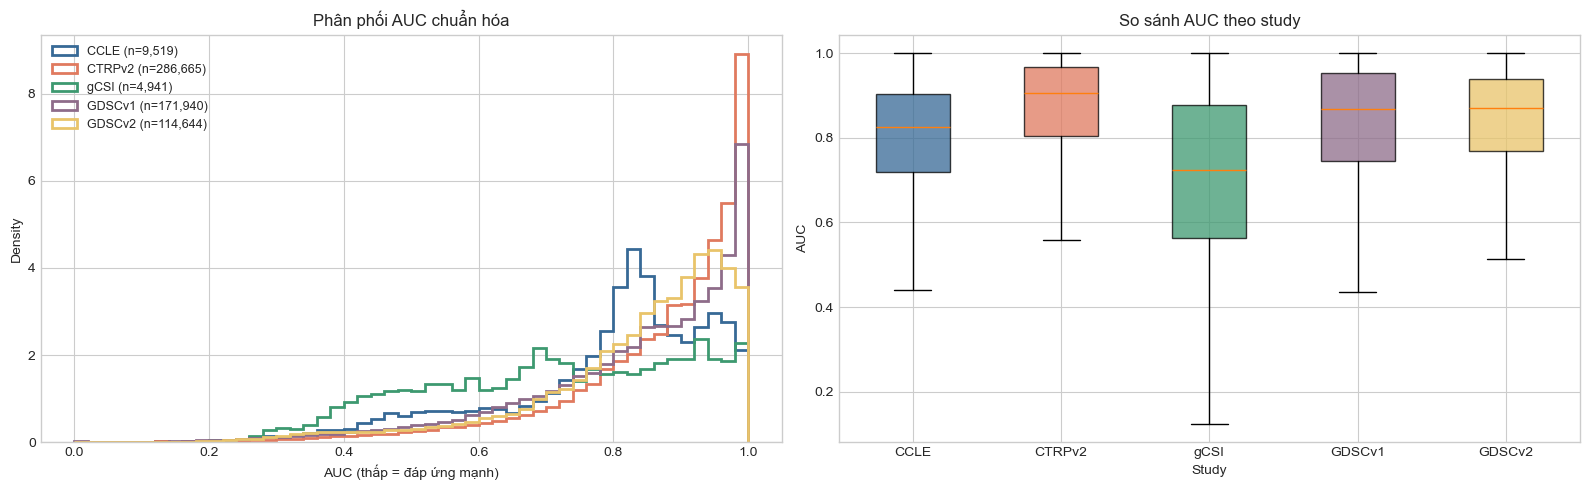

,AUC <= 0.2 (%),AUC <= 0.4 (%),AUC <= 0.6 (%),AUC <= 0.8 (%)
source,,,,
CCLE,0.1156,2.8785,15.0646,40.5820
CTRPv2,0.2020,1.5816,6.6859,24.3054
gCSI,0.0607,6.0716,29.9332,62.2344
GDSCv1,0.3199,2.6596,10.3088,34.0148
GDSCv2,0.1369,2.8340,9.1283,31.3920


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bins = np.linspace(0, 1, 51)
for study, color in zip(STUDIES, COLORS):
    values = response.loc[response.source == study, 'auc'].dropna()
    axes[0].hist(values, bins=bins, density=True, histtype='step', linewidth=2,
                 label=f'{study} (n={len(values):,})', color=color)
axes[0].set(title='Phân phối AUC chuẩn hóa', xlabel='AUC (thấp = đáp ứng mạnh)', ylabel='Density')
axes[0].legend(fontsize=9)

box_data = [response.loc[response.source == s, 'auc'].dropna().to_numpy() for s in STUDIES]
bp = axes[1].boxplot(box_data, labels=STUDIES, showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set(title='So sánh AUC theo study', xlabel='Study', ylabel='AUC')
plt.tight_layout()
plt.show()

thresholds = [0.2, 0.4, 0.6, 0.8]
sensitivity = pd.DataFrame({
    f'AUC <= {t} (%)': response.groupby('source', observed=True)['auc'].apply(lambda s: s.le(t).mean() * 100)
    for t in thresholds
})
display(sensitivity)

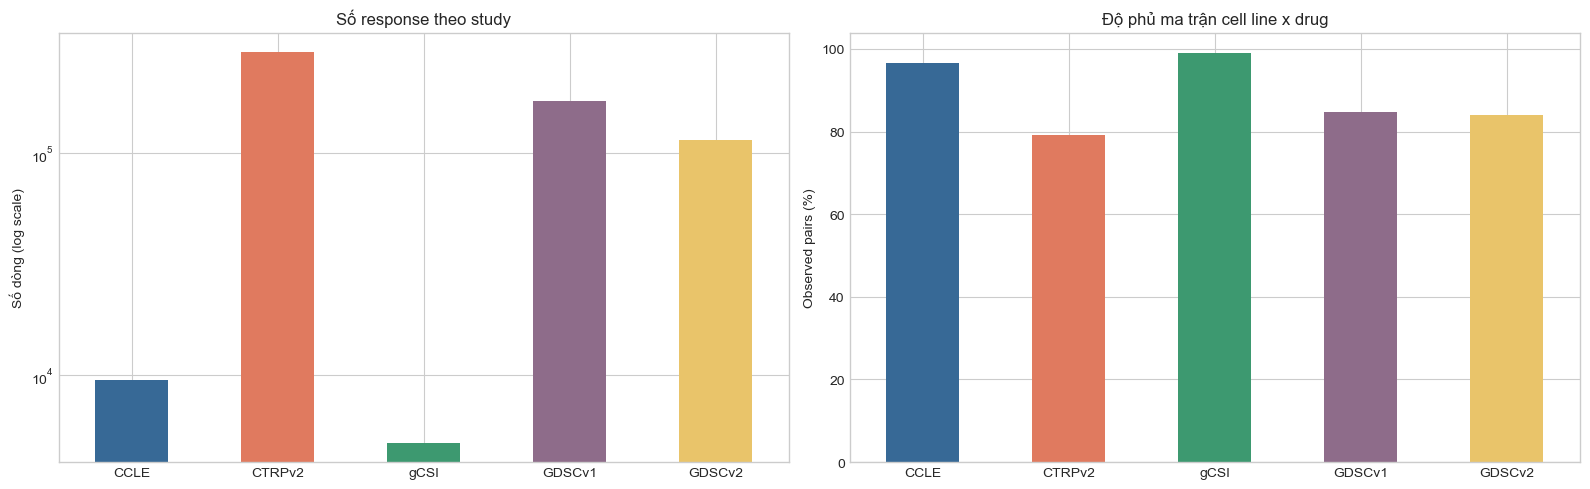

,drugs_per_cell_median,drugs_per_cell_min,drugs_per_cell_max,cells_per_drug_median,cells_per_drug_min,cells_per_drug_max
source,,,,,,
CCLE,24.0000,17,24,410.0000,263,411
CTRPv2,412.5000,4,456,657.0000,70,710
gCSI,16.0000,5,16,309.0000,305,312
GDSCv1,252.0000,25,294,510.0000,190,543
GDSCv2,150.0000,12,166,437.0000,37,469


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
summary['responses'].plot.bar(ax=axes[0], color=COLORS)
axes[0].set(title='Số response theo study', xlabel='', ylabel='Số dòng (log scale)', yscale='log')
axes[0].tick_params(axis='x', rotation=0)
summary['matrix_density_pct'].plot.bar(ax=axes[1], color=COLORS)
axes[1].set(title='Độ phủ ma trận cell line x drug', xlabel='', ylabel='Observed pairs (%)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

coverage_rows = []
for study in STUDIES:
    d = response[response.source == study]
    per_cell = d.groupby('improve_sample_id')['improve_chem_id'].nunique()
    per_drug = d.groupby('improve_chem_id')['improve_sample_id'].nunique()
    coverage_rows.append({
        'source': study,
        'drugs_per_cell_median': per_cell.median(),
        'drugs_per_cell_min': per_cell.min(),
        'drugs_per_cell_max': per_cell.max(),
        'cells_per_drug_median': per_drug.median(),
        'cells_per_drug_min': per_drug.min(),
        'cells_per_drug_max': per_drug.max(),
    })
display(pd.DataFrame(coverage_rows).set_index('source'))

## 4. Overlap giữa các dataset

Cross-dataset chỉ có thể đánh giá trực tiếp trên những drug/cell có feature chung. Ba ma trận dưới cho biết số phần tử giao nhau giữa từng cặp study.

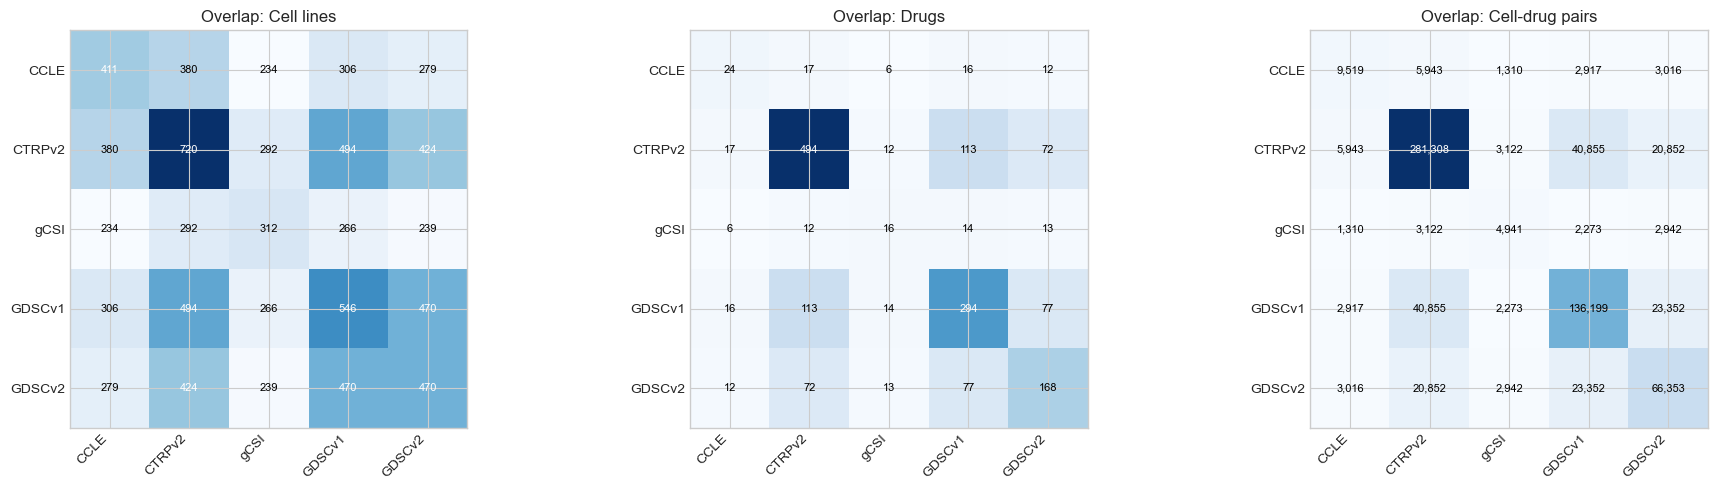

Cell lines


,CCLE,CTRPv2,gCSI,GDSCv1,GDSCv2
CCLE,411,380,234,306,279
CTRPv2,380,720,292,494,424
gCSI,234,292,312,266,239
GDSCv1,306,494,266,546,470
GDSCv2,279,424,239,470,470


Drugs


,CCLE,CTRPv2,gCSI,GDSCv1,GDSCv2
CCLE,24,17,6,16,12
CTRPv2,17,494,12,113,72
gCSI,6,12,16,14,13
GDSCv1,16,113,14,294,77
GDSCv2,12,72,13,77,168


Cell-drug pairs


,CCLE,CTRPv2,gCSI,GDSCv1,GDSCv2
CCLE,9519,5943,1310,2917,3016
CTRPv2,5943,281308,3122,40855,20852
gCSI,1310,3122,4941,2273,2942
GDSCv1,2917,40855,2273,136199,23352
GDSCv2,3016,20852,2942,23352,66353


In [12]:
entity_sets = {}
for study in STUDIES:
    d = response[response.source == study]
    entity_sets[study] = {
        'Cell lines': set(d.improve_sample_id.dropna()),
        'Drugs': set(d.improve_chem_id.dropna()),
        'Cell-drug pairs': set(zip(d.improve_sample_id, d.improve_chem_id)),
    }

def intersection_matrix(entity):
    return pd.DataFrame(
        [[len(entity_sets[a][entity] & entity_sets[b][entity]) for b in STUDIES] for a in STUDIES],
        index=STUDIES, columns=STUDIES,
    )

def annotated_heatmap(ax, matrix, title, cmap='Blues'):
    image = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    ax.set_title(title)
    cutoff = matrix.to_numpy().max() * 0.55
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iat[i, j]
            ax.text(j, i, f'{value:,}', ha='center', va='center', fontsize=8,
                    color='white' if value > cutoff else 'black')
    return image

overlap_matrices = {entity: intersection_matrix(entity) for entity in ['Cell lines', 'Drugs', 'Cell-drug pairs']}
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (entity, matrix) in zip(axes, overlap_matrices.items()):
    annotated_heatmap(ax, matrix, f'Overlap: {entity}')
plt.tight_layout()
plt.show()
for entity, matrix in overlap_matrices.items():
    print(entity)
    display(matrix)

## 5. Độ nhất quán AUC trên các cặp cell-drug trùng nhau

Mỗi khóa lặp trong cùng source được lấy AUC trung bình trước khi join. Pearson đo quan hệ tuyến tính, Spearman đo thứ hạng, còn MAE và mean bias cho biết chênh lệch tuyệt đối/hệ thống giữa hai study.

,source_a,source_b,shared_pairs,pearson,spearman,mae,mean_bias_a_minus_b
5,CTRPv2,GDSCv1,40855,0.6948,0.6288,0.0912,0.0110
9,GDSCv1,GDSCv2,23352,0.7447,0.6332,0.0936,-0.0197
6,CTRPv2,GDSCv2,20852,0.7950,0.7172,0.0774,-0.0064
0,CCLE,CTRPv2,5943,0.8238,0.7324,0.0788,-0.0286
4,CTRPv2,gCSI,3122,0.7386,0.7012,0.1061,-0.0009
3,CCLE,GDSCv2,3016,0.7075,0.5726,0.0947,-0.0423
8,gCSI,GDSCv2,2942,0.7124,0.6506,0.1149,-0.0313
2,CCLE,GDSCv1,2917,0.7818,0.6752,0.0882,-0.0068
7,gCSI,GDSCv1,2273,0.6877,0.6955,0.1240,0.0253
1,CCLE,gCSI,1310,0.7794,0.7264,0.0982,-0.0150


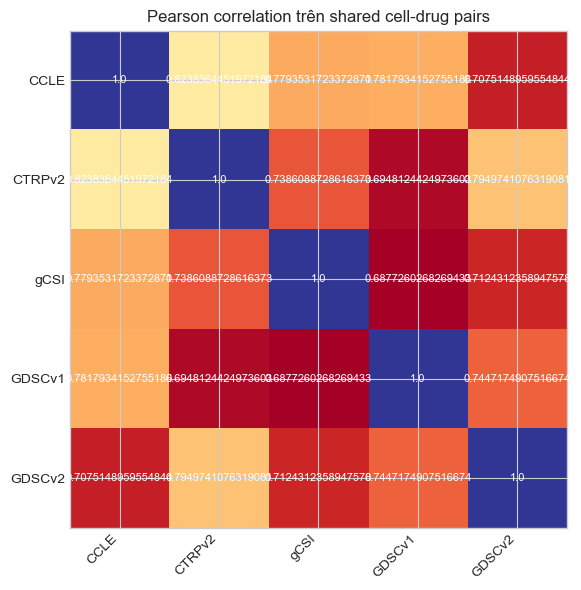

In [13]:
pair_auc = (
    response.groupby(key_cols, observed=True, as_index=False)['auc']
    .mean()
)
agreement_rows = []
joined_pairs = {}
for left, right in combinations(STUDIES, 2):
    a = pair_auc[pair_auc.source == left][['improve_sample_id', 'improve_chem_id', 'auc']]
    b = pair_auc[pair_auc.source == right][['improve_sample_id', 'improve_chem_id', 'auc']]
    joined = a.merge(b, on=['improve_sample_id', 'improve_chem_id'], suffixes=(f'_{left}', f'_{right}'))
    joined_pairs[(left, right)] = joined
    x, y = joined[f'auc_{left}'], joined[f'auc_{right}']
    agreement_rows.append({
        'source_a': left,
        'source_b': right,
        'shared_pairs': len(joined),
        'pearson': x.corr(y, method='pearson') if len(joined) >= 2 else np.nan,
        'spearman': x.corr(y, method='spearman') if len(joined) >= 2 else np.nan,
        'mae': (x - y).abs().mean(),
        'mean_bias_a_minus_b': (x - y).mean(),
    })
agreement = pd.DataFrame(agreement_rows).sort_values(['shared_pairs', 'pearson'], ascending=False)
display(agreement)

corr_matrix = pd.DataFrame(np.nan, index=STUDIES, columns=STUDIES)
for study in STUDIES:
    corr_matrix.loc[study, study] = 1.0
for row in agreement.itertuples():
    corr_matrix.loc[row.source_a, row.source_b] = row.pearson
    corr_matrix.loc[row.source_b, row.source_a] = row.pearson
fig, ax = plt.subplots(figsize=(7, 6))
annotated_heatmap(ax, corr_matrix, 'Pearson correlation trên shared cell-drug pairs', cmap='RdYlBu')
plt.tight_layout()
plt.show()

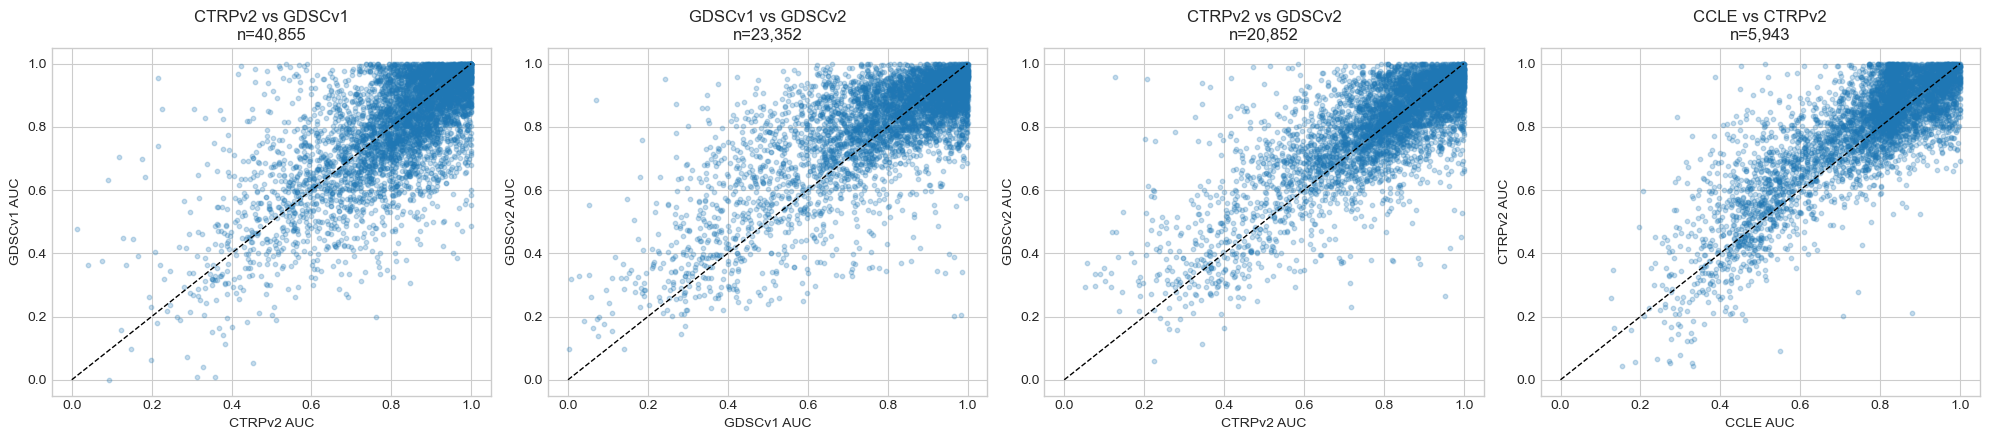

In [14]:
eligible = agreement[agreement.shared_pairs >= 20]
if eligible.empty:
    print('Không có cặp study nào có ít nhất 20 shared pairs để vẽ scatter.')
else:
    top_pairs = list(eligible.head(4)[['source_a', 'source_b']].itertuples(index=False, name=None))
    fig, axes = plt.subplots(1, len(top_pairs), figsize=(5 * len(top_pairs), 4.5), squeeze=False)
    for ax, (left, right) in zip(axes.ravel(), top_pairs):
        d = joined_pairs[(left, right)]
        if len(d) > 5000:
            d = d.sample(5000, random_state=RANDOM_STATE)
        ax.scatter(d[f'auc_{left}'], d[f'auc_{right}'], s=10, alpha=0.25)
        ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1)
        ax.set(xlabel=f'{left} AUC', ylabel=f'{right} AUC', title=f'{left} vs {right}\nn={len(joined_pairs[(left, right)]):,}')
    plt.tight_layout()
    plt.show()

## 6. Audit feature coverage

Phần này kiểm tra liệu ID trong response có feature tương ứng hay không. Đây là bước quan trọng vì model chỉ sử dụng được giao giữa response, omics và drug representation.

In [15]:
# get_x_data là loader chuẩn của IMPROVE và trả ID dưới dạng index.
mordred = frm.get_x_data(
    file='drug_mordred.tsv', benchmark_dir=DATA_DIR, column_name='improve_chem_id'
)
ecfp = frm.get_x_data(
    file='drug_ecfp4_nbits512.tsv', benchmark_dir=DATA_DIR, column_name='improve_chem_id'
)
drug_info = frm.get_x_data(
    file='drug_info.tsv', benchmark_dir=DATA_DIR, column_name='improve_chem_id'
)

# Hai dòng đầu sau header của gene-expression chứa Entrez ID và gene symbol.
# Chỉ đọc cột ID để audit coverage, tránh nạp toàn bộ ma trận 30,805 gene.
gene_ids = pd.read_csv(
    X_DIR / 'cancer_gene_expression.tsv', sep='\t', usecols=[0], skiprows=[1, 2]
).iloc[:, 0].dropna().astype(str)

feature_ids = {
    'gene_expression': set(gene_ids),
    'mordred': set(mordred.index.dropna().astype(str)),
    'ecfp512': set(ecfp.index.dropna().astype(str)),
    'drug_info': set(drug_info.index.dropna().astype(str)),
}
coverage = []
for study in STUDIES:
    d = response[response.source == study]
    cells = set(d.improve_sample_id.dropna().astype(str))
    drugs = set(d.improve_chem_id.dropna().astype(str))
    coverage.append({
        'source': study,
        'response_cells': len(cells),
        'cells_with_gene_expression': len(cells & feature_ids['gene_expression']),
        'cell_coverage_pct': len(cells & feature_ids['gene_expression']) / len(cells) * 100,
        'response_drugs': len(drugs),
        'drugs_with_mordred': len(drugs & feature_ids['mordred']),
        'drugs_with_ecfp512': len(drugs & feature_ids['ecfp512']),
        'mordred_coverage_pct': len(drugs & feature_ids['mordred']) / len(drugs) * 100,
    })
display(pd.DataFrame(coverage).set_index('source'))
print('Feature table shapes:')
print('  Gene expression IDs:', len(gene_ids))
print('  Mordred:', mordred.shape)
print('  ECFP512:', ecfp.shape)
print('  Drug info:', drug_info.shape)

,response_cells,cells_with_gene_expression,cell_coverage_pct,response_drugs,drugs_with_mordred,drugs_with_ecfp512,mordred_coverage_pct
source,,,,,,,
CCLE,411,411,100.0000,24,24,24,100.0000
CTRPv2,720,720,100.0000,494,494,494,100.0000
gCSI,312,312,100.0000,16,16,16,100.0000
GDSCv1,546,546,100.0000,294,294,294,100.0000
GDSCv2,470,470,100.0000,168,168,168,100.0000


Feature table shapes:
  Gene expression IDs: 1007
  Mordred: (1565, 1613)
  ECFP512: (1565, 512)
  Drug info: (2145, 6)


,rows,features,missing_cells_pct,features_with_any_missing_pct,constant_features,infinite_values
Mordred,"1,565.0000","1,613.0000",0.0000,0.0000,211.0000,0.0000
ECFP512,"1,565.0000",512.0000,0.0000,0.0000,0.0000,0.0000


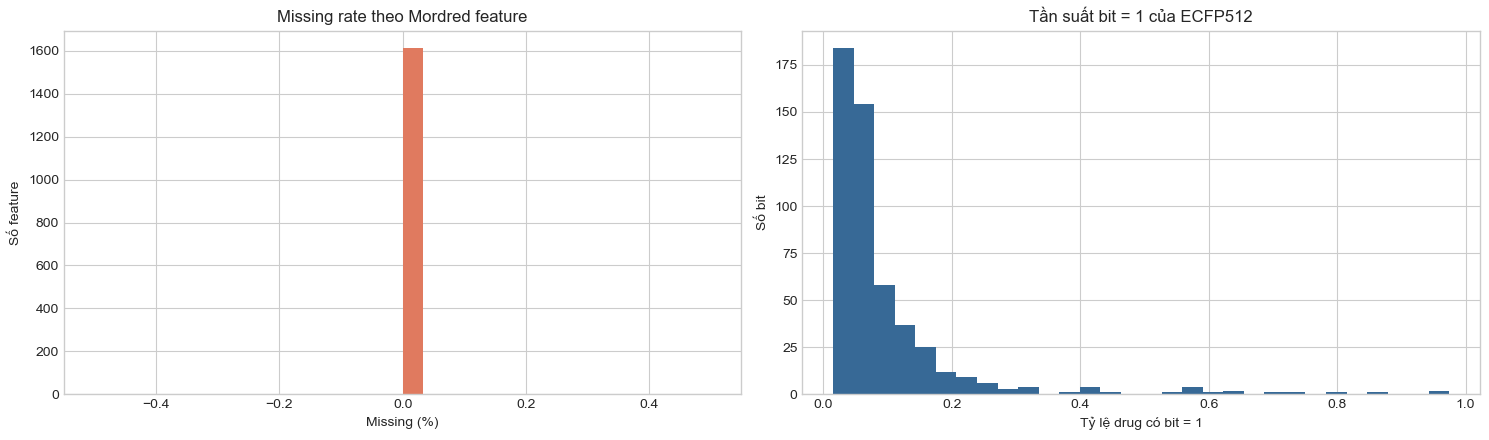

In [16]:
def numeric_feature_report(df, name):
    features = df.apply(pd.to_numeric, errors='coerce')
    report = pd.Series({
        'rows': len(features),
        'features': features.shape[1],
        'missing_cells_pct': features.isna().mean().mean() * 100,
        'features_with_any_missing_pct': features.isna().any().mean() * 100,
        'constant_features': features.nunique(dropna=True).le(1).sum(),
        'infinite_values': np.isinf(features.to_numpy(dtype=float, na_value=np.nan)).sum(),
    }, name=name)
    return features, report

mordred_x, mordred_report = numeric_feature_report(mordred, 'Mordred')
ecfp_x, ecfp_report = numeric_feature_report(ecfp, 'ECFP512')
display(pd.concat([mordred_report, ecfp_report], axis=1).T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
mordred_x.isna().mean().mul(100).hist(bins=30, ax=axes[0], color=COLORS[1])
axes[0].set(title='Missing rate theo Mordred feature', xlabel='Missing (%)', ylabel='Số feature')
bit_prevalence = ecfp_x.mean(axis=0)
bit_prevalence.hist(bins=30, ax=axes[1], color=COLORS[0])
axes[1].set(title='Tần suất bit = 1 của ECFP512', xlabel='Tỷ lệ drug có bit = 1', ylabel='Số bit')
plt.tight_layout()
plt.show()

## 7. PCA mẫu của gene expression

File gene expression có 30,805 gene và dung lượng lớn. Để EDA nhẹ RAM, cell dưới lấy tối đa 1,500 gene cách đều trên header, loại gene hằng số, median-impute rồi PCA. Đây chỉ là hình dung cấu trúc dữ liệu, không thay thế pipeline preprocessing của model.

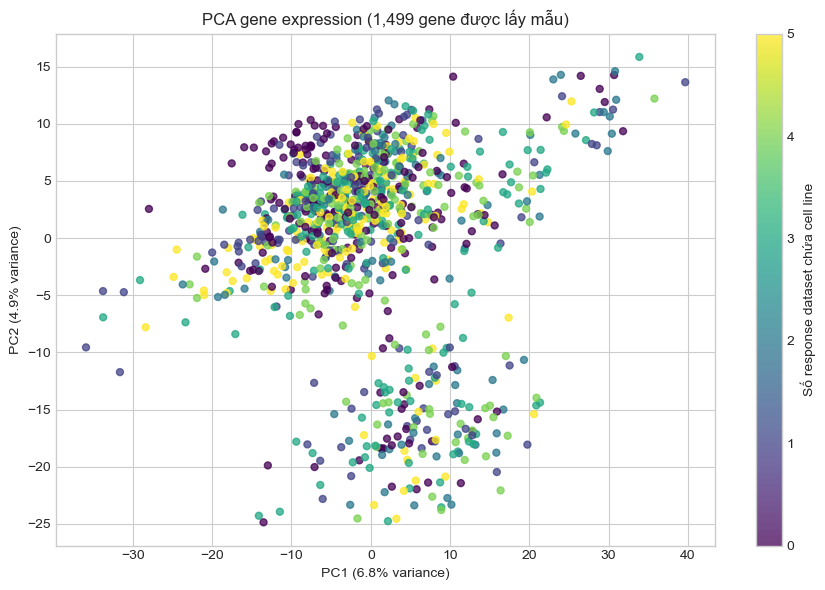

,PC1,PC2,improve_sample_id,datasets,n_datasets
0,-8.2510,3.4365,ACH-000016,No response,0
1,19.7575,-18.0681,ACH-000032,CTRPv2,1
2,1.7964,7.4828,ACH-000033,No response,0
3,-12.4979,6.5168,ACH-000043,No response,0
4,-7.0531,3.3933,ACH-000049,No response,0


In [17]:
GE_FILE = X_DIR / 'cancer_gene_expression.tsv'
with GE_FILE.open(newline='') as handle:
    header = next(csv.reader(handle, delimiter='\t'))
gene_cols = header[1:]
n_sample_genes = min(1500, len(gene_cols))
positions = np.linspace(0, len(gene_cols) - 1, n_sample_genes, dtype=int)
sampled_genes = [gene_cols[i] for i in np.unique(positions)]
usecol_positions = [0] + [int(i) + 1 for i in np.unique(positions)]

gene_expression = pd.read_csv(
    GE_FILE,
    sep='\t',
    usecols=usecol_positions,
    skiprows=[1, 2],
    low_memory=False,
)
gene_expression = gene_expression.rename(columns={gene_expression.columns[0]: 'improve_sample_id'})
ge_x = gene_expression.drop(columns='improve_sample_id').apply(pd.to_numeric, errors='coerce')
ge_x = ge_x.loc[:, ge_x.nunique(dropna=True) > 1]
ge_x = ge_x.fillna(ge_x.median())

scaled = StandardScaler().fit_transform(ge_x)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
pca_df['improve_sample_id'] = gene_expression['improve_sample_id'].astype(str).values

sample_sources = response.groupby('improve_sample_id', observed=True)['source'].apply(
    lambda s: ', '.join(map(str, pd.unique(s.dropna())))
)
pca_df['datasets'] = pca_df.improve_sample_id.map(sample_sources).fillna('No response')
pca_df['n_datasets'] = pca_df.datasets.str.count(',') + 1
pca_df.loc[pca_df.datasets == 'No response', 'n_datasets'] = 0

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(pca_df.PC1, pca_df.PC2, c=pca_df.n_datasets, cmap='viridis', s=25, alpha=0.75)
ax.set(
    title=f'PCA gene expression ({ge_x.shape[1]:,} gene được lấy mẫu)',
    xlabel=f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)',
    ylabel=f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)',
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Số response dataset chứa cell line')
plt.tight_layout()
plt.show()
display(pca_df.head())

## 8. Audit 10-fold split chính thức

Paper tạo 10 bộ train/validation/test ngẫu nhiên với tỷ lệ 0.8/0.1/0.1. Audit kiểm tra file tồn tại, index hợp lệ, ba tập rời nhau, union phủ toàn bộ study và phân phối AUC giữa các stage.

In [18]:
split_rows = []
response_by_index = response.set_index('index')
for study in STUDIES:
    expected_ids = set(response.loc[response.source == study, 'index'].astype(int))
    n = len(expected_ids)
    for fold in range(10):
        stage_indices = {}
        for stage in ['train', 'val', 'test']:
            split_file = SPLIT_DIR / f'{study}_split_{fold}_{stage}.txt'
            indices = np.atleast_1d(np.loadtxt(split_file, dtype=int))
            stage_indices[stage] = set(indices.tolist())
            y = response_by_index.loc[indices, 'auc']
            split_rows.append({
                'source': study,
                'fold': fold,
                'stage': stage,
                'n': len(indices),
                'fraction': len(indices) / n,
                'auc_mean': y.mean(),
                'auc_std': y.std(),
                'min_index': indices.min(),
                'max_index': indices.max(),
            })
        disjoint = (
            stage_indices['train'].isdisjoint(stage_indices['val'])
            and stage_indices['train'].isdisjoint(stage_indices['test'])
            and stage_indices['val'].isdisjoint(stage_indices['test'])
        )
        union = set().union(*stage_indices.values())
        assert disjoint, f'Overlap index: {study}, fold {fold}'
        assert union == expected_ids, f'Split không phủ đủ dữ liệu: {study}, fold {fold}'

split_audit = pd.DataFrame(split_rows)
display(split_audit.groupby(['source', 'stage'], observed=True).agg(
    n_min=('n', 'min'), n_max=('n', 'max'),
    fraction_mean=('fraction', 'mean'),
    auc_mean_across_folds=('auc_mean', 'mean'),
    auc_mean_fold_std=('auc_mean', 'std'),
))
print('PASS: cả 50 bộ split đều rời nhau, index hợp lệ và phủ toàn bộ response của study.')

n_min   n_max  fraction_mean  auc_mean_across_folds  \
source stage                                                         
CCLE   test      951     952         0.1000                 0.7856   
       train    7615    7616         0.8000                 0.7856   
       val       951     952         0.1000                 0.7856   
CTRPv2 test    28666   28667         0.1000                 0.8614   
       train  229331  229333         0.8000                 0.8614   
       val     28666   28667         0.1000                 0.8614   
GDSCv1 test    17194   17194         0.1000                 0.8247   
       train  137552  137552         0.8000                 0.8247   
       val     17194   17194         0.1000                 0.8247   
GDSCv2 test    11464   11465         0.1000                 0.8272   
       train   91714   91716         0.8000                 0.8272   
       val     11464   11465         0.1000                 0.8272   
gCSI   test      494     495         0.1000                 0.7111   
       train    3952    3953         0.8000                 0.7111   
       val       494     495         0.1000                 0.7111   

              auc_mean_fold_std  
source stage                     
CCLE   test              0.0047  
       train             0.0007  
       val               0.0047  
CTRPv2 test              0.0009  
       train             0.0002  
       val               0.0009  
GDSCv1 test              0.0009  
       train             0.0002  
       val               0.0009  
GDSCv2 test              0.0015  
       train             0.0002  
       val               0.0015  
gCSI   test              0.0094  
       train             0.0014  
       val               0.0094

PASS: cả 50 bộ split đều rời nhau, index hợp lệ và phủ toàn bộ response của study.


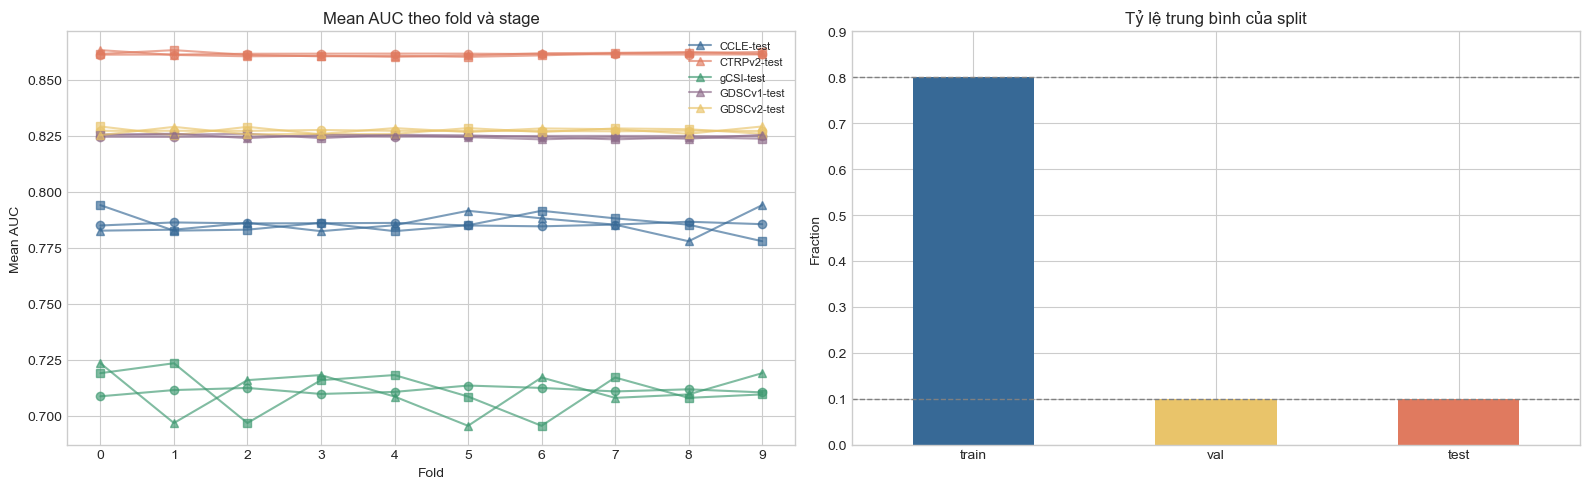

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for stage, marker in zip(['train', 'val', 'test'], ['o', 's', '^']):
    part = split_audit[split_audit.stage == stage]
    for study, color in zip(STUDIES, COLORS):
        d = part[part.source == study]
        axes[0].plot(d.fold, d.auc_mean, marker=marker, color=color, alpha=0.65,
                     label=f'{study}-{stage}' if stage == 'test' else None)
axes[0].set(title='Mean AUC theo fold và stage', xlabel='Fold', ylabel='Mean AUC', xticks=range(10))
axes[0].legend(fontsize=8)

fraction_pivot = split_audit.groupby('stage')['fraction'].mean().reindex(['train', 'val', 'test'])
fraction_pivot.plot.bar(ax=axes[1], color=['#376996', '#E9C46A', '#E07A5F'])
axes[1].axhline(0.8, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(0.1, color='gray', linestyle='--', linewidth=1)
axes[1].set(title='Tỷ lệ trung bình của split', xlabel='', ylabel='Fraction', ylim=(0, 0.9))
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Kết luận EDA cần báo cáo

Sau khi chạy toàn bộ notebook, nên tổng hợp các điểm sau vào báo cáo:

1. **Quy mô rất lệch:** CTRPv2 lớn nhất, còn CCLE và gCSI nhỏ hơn nhiều; vì vậy sai số và độ ổn định mô hình không thể so sánh chỉ bằng một metric trung bình.
2. **Dataset shift:** so sánh histogram, quantile và tỷ lệ AUC dưới các threshold để xác định study nào nhạy/kháng hơn về mặt phân phối.
3. **Overlap quyết định transfer:** báo cáo số drug, cell line và cell-drug pair dùng chung. Overlap thấp làm cross-dataset khó hơn, ngay cả khi feature space chung.
4. **Measurement disagreement:** Pearson/Spearman thấp hoặc bias lớn trên shared pairs cho thấy khác biệt protocol thí nghiệm, không chỉ là lỗi mô hình.
5. **Feature coverage và quality:** xác nhận các response ID có gene expression/Mordred/ECFP; loại feature hằng số và xử lý missing chỉ dựa trên train khi xây model.
6. **Split integrity:** 10 split chính thức là random response split, không phải cold-drug/cold-cell split. Vì vậy within-dataset score có thể hưởng lợi khi drug/cell xuất hiện ở cả train và test.

### Khuyến nghị cho bước modeling
- dùng đúng split chính thức để tái lập paper;
- fit scaler, imputer, feature selection và PCA **chỉ trên train** để tránh leakage;
- báo cáo cả within-dataset và cross-dataset, kèm RMSE/MAE/Pearson và độ giảm hiệu năng;
- bổ sung cold-cell hoặc cold-drug split nếu mục tiêu là generalization tới thực thể chưa từng thấy.